# Factory diagnostics — run this on *your* machine

Our numbers are not yours. A batch size that saturates a 96 GB workstation card starves a Colab
T4. So rather than copying settings out of a table, this measures the box you are on and tells
you what the measurements mean.

1. **What am I running on?** GPUs, memory, precision, whether the fleet can help.
2. **Is there enough text, and is it any good?** Corpus size against your planned rungs, spelling
   consistency, variety, and how well the vocabulary fits the language.
3. **What batch size, and what is my bottleneck?** Swept here, with the reasoning shown.
4. **What will the study cost?** Projected from the throughput just measured.

Nothing here trains anything you keep. A couple of minutes end to end.


In [1]:
import os, sys
FACTORY_DIR = os.environ.get("FACTORY_DIR", os.getcwd())
if FACTORY_DIR not in sys.path:
    sys.path.insert(0, FACTORY_DIR)

CORPUS  = "yor"     # your prepared corpus, or None to measure hardware only
PRESET  = "poc"     # "poc" or "afriberta"
SEQ_LEN = 128
RUNGS   = [4_000_000, 16_000_000, 64_000_000]

import diagnose, audit_corpus
import matplotlib.pyplot as plt

C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"
INK2, MUTED, GRID = "#52514e", "#8a8985", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": GRID,
    "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": .8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "legend.frameon": False, "lines.linewidth": 2.0, "lines.markersize": 8})

## 1 · What am I running on?

In [2]:
env = diagnose.describe_environment()
diagnose.print_environment(env)
assert env["gpus"], "no GPU -- on Colab: Runtime > Change runtime type > GPU"


  running on   Windows | python 3.12.13 | torch 2.11.0+cu128 | CUDA 12.8
  GPU 0        NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition | 103 GB | compute 12.0 | 188 SMs
  GPU 1        NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition | 103 GB | compute 12.0 | 188 SMs
  precision    bf16 (no loss scaler needed)
  parallelism  2 cards -> mlm_fleet.py runs 2 cells at once


## 2 · Is there enough text, and is it any good?

In [3]:
if CORPUS:
    diagnose.size_corpus(CORPUS, RUNGS)


  corpus 'yor': 69,096,452 train tokens, vocab 16,000, 3.73 chars/token
  resident store: 0.138 GB as int16

            rung   share of corpus
       4,000,000               6%
      16,000,000              23%
      64,000,000              93%

  the top rung uses most of the available text -- there is little headroom to grow the data axis.


In [4]:
if CORPUS:
    import mlm_api as factory
    from audit_corpus import WORD, orthographic_consistency, repetition, fertility

    docs  = factory.sample_docs(CORPUS, 3000)
    words = WORD.findall("\n".join(docs))
    orth  = orthographic_consistency(words)
    rep   = repetition(docs)
    ttr   = len(set(w.lower() for w in words)) / max(len(words), 1)

    print(f"{len(words):,} words sampled")
    print(f"  diacritics on {orth['marked_share']:.1%} of word occurrences")
    print(f"  type/token ratio {ttr:.3f}   repeated lines {rep['repeated_share']:.1%}")
    if orth["split_words"]:
        print("\n  same word, more than one spelling -- each is a separate token:")
        for bare, total, bare_n, forms in orth["split_words"][:6]:
            print(f"    {bare:<12}{total:>8,} uses   {', '.join(w for w, _ in forms)}")

1,970,158 words sampled
  diacritics on 35.4% of word occurrences
  type/token ratio 0.031   repeated lines 3.2%

  same word, more than one spelling -- each is a separate token:
    ti           105,743 uses   ti, tí, tì
    awon          94,445 uses   awọn, àwọn, awon
    o             78,079 uses   o, ọ, ó
    ni            75,583 uses   ni, ní, nì
    ati           38,073 uses   ati, àti, àtí
    lati          33,245 uses   lati, láti, làti


### Does the vocabulary fit the language?

Tokens per word. Lower is better — a tokenizer that fragments your language spends the model's
context window on pieces of words instead of words.

findfont: Failed to find font weight 600, now using 700.


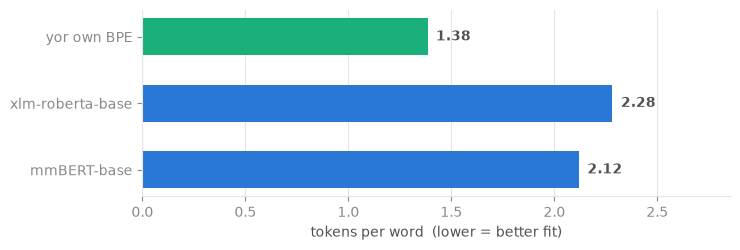

the multilingual vocabularies need 1.65x as many tokens for the same text


In [5]:
if CORPUS:
    OTHERS = ["FacebookAI/xlm-roberta-base", "jhu-clsp/mmBERT-base"]
    sample = [d[:2000] for d in docs[:200]]
    names  = [f"{CORPUS} own BPE"]
    vals   = [fertility(factory.load_tokenizer(CORPUS), sample)]

    from transformers import AutoTokenizer
    for nm in OTHERS:
        try:
            vals.append(fertility(AutoTokenizer.from_pretrained(nm), sample))
            names.append(nm.split("/")[-1])
        except Exception as e:
            print(f"{nm}: {repr(e)[:60]}")

    fig, ax = plt.subplots(figsize=(7.5, 2.6))
    colors = [C3] + [C1] * (len(vals) - 1)
    ax.barh(names[::-1], vals[::-1], color=colors[::-1], height=.55)
    for i, v in enumerate(vals[::-1]):
        ax.annotate(f"{v:.2f}", (v, i), xytext=(6, 0), textcoords="offset points",
                    va="center", color=INK2, fontsize=10, fontweight=600)
    ax.set_xlabel("tokens per word  (lower = better fit)")
    ax.set_xlim(0, max(vals) * 1.25)
    ax.grid(axis="y", visible=False)
    plt.tight_layout(); plt.show()
    print(f"the multilingual vocabularies need {max(vals)/vals[0]:.2f}x as many "
          f"tokens for the same text")

## 3 · What batch size, and what is my bottleneck?

A dozen real training steps at each batch size, stopping when it runs out of memory.

In [6]:
rows = diagnose.sweep_batches(CORPUS, PRESET, SEQ_LEN, gpu=0, steps=12)
d = diagnose.diagnose(rows, env, env["gpus"][0]["memory_gb"])
diagnose.print_verdict(d, env)


  sweeping batch sizes on corpus 'yor', preset 'poc', seq_len 128 ...


    batch   16      132k tok/s      1.3 GB peak      27 TFLOP/s


    batch   32      222k tok/s      1.9 GB peak      45 TFLOP/s


    batch   64      354k tok/s      3.3 GB peak      72 TFLOP/s


    batch  128      472k tok/s      6.1 GB peak      96 TFLOP/s


    batch  256      486k tok/s     11.6 GB peak      98 TFLOP/s


    batch  512      467k tok/s     22.8 GB peak      95 TFLOP/s

  ----------------------------------------------------------------------
  RECOMMENDED BATCH  128   (472k tok/s, 6.1 GB peak)
  BOTTLENECK         model size (launch-bound)
  ----------------------------------------------------------------------
    - throughput plateaus while using only 6% of memory, so the card is not short of room -- the model is too small to keep it busy, and the time goes into starting and finishing small kernels
    - 2 cards are available and one run uses one card, so the fleet is worth up to 2x on a multi-cell grid
    - batch 256 was marginally faster (486k vs 472k tok/s) but costs 1.9x the memory and halves the optimizer steps at a fixed token budget, so the smaller one is recommended

  use it with:  --batch 128   (and mlm_fleet.py will use all 2 cards)


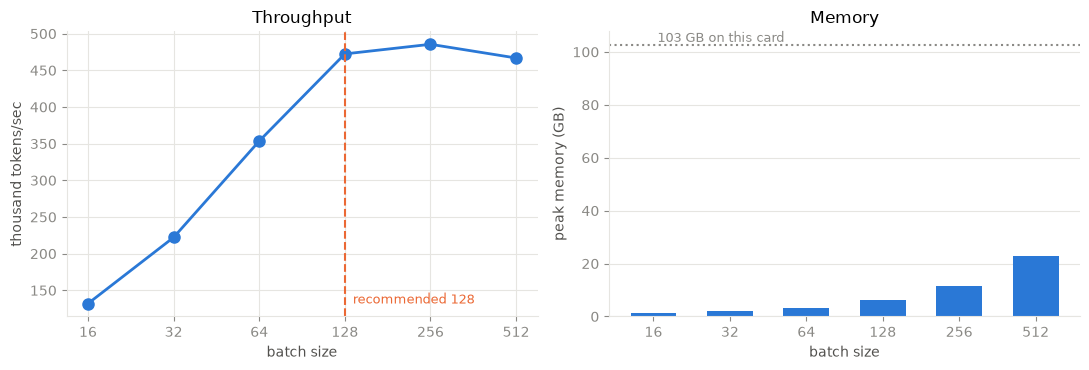

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
b = [r["batch"] for r in rows]

ax[0].plot(b, [r["tok_s"] / 1e3 for r in rows], "o-", color=C1)
ax[0].axvline(d["best_batch"], color=C2, ls="--", lw=1.5)
ax[0].annotate(f"  recommended {d['best_batch']}", (d["best_batch"], min(r["tok_s"] for r in rows) / 1e3),
               color=C2, fontsize=9)
ax[0].set_xscale("log", base=2); ax[0].set_xticks(b); ax[0].set_xticklabels(b)
ax[0].set_xlabel("batch size"); ax[0].set_ylabel("thousand tokens/sec")
ax[0].set_title("Throughput")

total = env["gpus"][0]["memory_gb"]
ax[1].bar([str(x) for x in b], [r["peak_gb"] for r in rows], color=C1, width=.6)
ax[1].axhline(total, color=MUTED, ls=":", lw=1.5)
ax[1].annotate(f" {total:.0f} GB on this card", (0, total), color=MUTED, fontsize=9, va="bottom")
ax[1].set_xlabel("batch size"); ax[1].set_ylabel("peak memory (GB)")
ax[1].set_title("Memory"); ax[1].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## 4 · What will the study cost here?

In [8]:
total_h = diagnose.project(d["best_tok_s"], PRESET, "afriberta", RUNGS, passes=12)
if env["n_gpu"] > 1:
    print(f"\n  on {env['n_gpu']} cards: about {total_h / env['n_gpu']:.2f} h wall-clock per language")
else:
    print("\n  one card: wall-clock equals the GPU-hours above")
print(f"\n  next:  python mlm_fleet.py --corpus {CORPUS} --queue poc --batch {d['best_batch']}")


  cost on this machine, 12 passes per rung, scaled to 'afriberta' (3.4x cost/token)

            rung     tokens seen   GPU-hours
       4,000,000      48,000,000        0.10
      16,000,000     192,000,000        0.38
      64,000,000     768,000,000        1.52
    per language                        2.00

  on 2 cards: about 1.00 h wall-clock per language

  next:  python mlm_fleet.py --corpus yor --queue poc --batch 128


---

## Reading the verdict

- **Use the recommended batch.** It came from this machine; ours will not match yours. It is the
  *knee* of the curve, not the peak — a slightly faster larger batch costs memory and takes fewer
  optimizer steps for the same work, which changes the optimization rather than just the speed.
- **"model size (launch-bound)"** — the card is not full and cannot be filled by tuning; the model
  is simply small. Expected at POC scale, and it improves at AfriBERTa scale.
- **"memory"** — you hit the wall. Reduce `SEQ_LEN` or the preset before reducing the batch.
- **"batch size (untested headroom)"** — throughput was still climbing at the largest batch tried;
  add larger values to `diagnose.BATCHES` and re-run.
- **A rung that does not fit your corpus** silently just repeats the text more times. Lower the
  ladder or add sources.
